# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [3]:
def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'.

        mse  = mean of the squared errors
        rmse = square root of mse
        mae  = mean of the absolute errors
        r2   = 1 - (sum of squared errors) / (sum of squared deviations
               of y_true from its own mean)

    Return Python/NumPy floats. Do not import from sklearn.metrics.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    errors = y_true - y_pred
    mse = float(np.mean(errors ** 2))             # штраф за ВЕЛИКІ помилки квадратичний ->
                                                  # чутливий до викидів у прогнозі
    rmse = float(np.sqrt(mse))                    # той самий штраф, але повернутий в одиниці
                                                  # вихідної змінної (легше інтерпретувати)
    mae = float(np.mean(np.abs(errors)))          # штраф лінійний -> стійкіший до окремих
                                                  # великих промахів, ніж mse/rmse

    ss_res = np.sum(errors ** 2)                  # залишкова сума квадратів (те, що НЕ пояснила модель)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)# повна сума квадратів (дисперсія y_true
                                                  # відносно наївного прогнозу "завжди середнє")
    r2 = float(1 - ss_res / ss_tot)               # частка дисперсії y, яку пояснює модель;
                                                  # r2=1 - ідеальний прогноз, r2=0 - модель не
                                                  # краща за прогноз "завжди середнє", r2<0 - гірша

    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [5]:
# Та сама таблиця bikes, завантажена в Setup
bikes_frame = bikes

# --- базова модель: temp, hum, windspeed -> cnt, спліт 75/25 ---
feature_cols = ["temp", "hum", "windspeed"]
X = bikes_frame[feature_cols].values
y = bikes_frame["cnt"].values

idx_train, idx_test = train_test_split(bikes_frame.index.values, test_size=0.25, random_state=SEED)

model = LinearRegression()
model.fit(X[idx_train], y[idx_train])
y_pred_test = model.predict(X[idx_test])
y_true_test = y[idx_test]

metrics = regression_metrics(y_true_test, y_pred_test)
print({k: round(v, 4) for k, v in metrics.items()})
print(f"середній cnt у test: {y_true_test.mean():.1f}")

ratio = metrics["rmse"] / metrics["mae"]
print(f"RMSE/MAE = {ratio:.3f}")

# (b) десять найгірше передбачених годин
worst = bikes_frame.loc[idx_test].copy()
worst["y_true"] = y_true_test
worst["y_pred"] = y_pred_test
worst["abs_error"] = np.abs(y_true_test - y_pred_test)
worst_10 = worst.sort_values("abs_error", ascending=False).head(10)
print(worst_10[["dteday", "hr", "workingday", "weathersit", "temp", "y_true", "y_pred", "abs_error"]]
      .round(1).to_string())
print(f"\nчастка похибки: 10 найгірших годин = {worst_10['abs_error'].sum() / worst['abs_error'].sum():.2%} "
      f"від суми |помилок| на {len(worst)} годинах")

# (c) додаємо one-hot hr
hr_dummies = pd.get_dummies(bikes_frame["hr"], prefix="hr", drop_first=True)
X_full = pd.concat([bikes_frame[feature_cols], hr_dummies], axis=1).values

model_hr = LinearRegression()
model_hr.fit(X_full[idx_train], y[idx_train])
y_pred_hr = model_hr.predict(X_full[idx_test])
metrics_hr = regression_metrics(y[idx_test], y_pred_hr)
print({k: round(v, 4) for k, v in metrics_hr.items()})
print(f"ΔR² = {metrics_hr['r2'] - metrics['r2']:.3f}")

# для порівняння: hr як одне ціле число
X_int = bikes_frame[feature_cols + ["hr"]].values
m_int = LinearRegression().fit(X_int[idx_train], y[idx_train])
print(f"R² з hr як цілим числом: {regression_metrics(y[idx_test], m_int.predict(X_int[idx_test]))['r2']:.4f}")

{'mse': 25094.1254, 'rmse': 158.4113, 'mae': 118.9047, 'r2': 0.2511}
середній cnt у test: 191.1
RMSE/MAE = 1.332
           dteday  hr  workingday  weathersit   temp  y_true   y_pred  abs_error
15132  2012-09-27  17           1           2 0.7000     905 232.4000   672.6000
15276  2012-10-03  17           1           1 0.7000     917 254.8000   662.2000
15771  2012-10-24   8           1           2 0.5000     801 141.3000   659.7000
15099  2012-09-26   8           1           1 0.6000     838 185.3000   652.7000
15267  2012-10-03   8           1           2 0.6000     809 163.7000   645.3000
15756  2012-10-23  17           1           1 0.7000     938 313.5000   624.5000
11283  2012-04-20   8           1           1 0.4000     700  81.1000   618.9000
14220  2012-08-20  17           1           1 0.7000     893 277.0000   616.0000
15747  2012-10-23   8           1           2 0.5000     761 149.7000   611.3000
15483  2012-10-12   8           1           1 0.4000     745 138.0000   607.0

**Your answer:**

Метрики `LinearRegression(temp, hum, windspeed)` на test (25%, 4345 годин): **MSE = 25 094, RMSE = 158.4, MAE = 118.9, R² = 0.251**. Середній `cnt` у test — 191 поїздка на годину.

**(a)** RMSE ≈ 158 означає, що типова помилка моделі — близько **158 велосипедів на годину**, у тих самих одиницях, що й `cnt`. Це дуже багато при середньому попиті 191: модель майже не знає, скільки буде поїздок. Точніше, RMSE — корінь із середнього квадрата помилки, тож він сильніше зважує великі промахи, ніж звичайне середнє. MSE ≈ 25 094 так читати не можна: це середнє **квадратів** помилок, його одиниця — «велосипеди²», якій не відповідає жодна фізична величина. MSE корисний як функція втрат і для порівняння моделей між собою, але не для відповіді на питання «на скільки велосипедів модель помиляється».

**(b)** RMSE / MAE = **1.33**. RMSE ≥ MAE завжди, і рівність можлива лише тоді, коли всі помилки однакові за модулем. Відношення, помітно більше за 1, означає, що помилки дуже нерівні: більшість годин модель промахується помірно, а частина — дуже сильно, і квадратичне зважування в RMSE ці великі промахи підсилює. Десять найгірше передбачених годин мають спільне: **усі — робочі дні, усі — о 8:00 або о 17:00, і всі у 2012 році** (квітень–жовтень). Фактично там було 700–938 поїздок, а модель прогнозувала лише 81–314. Це ранкові й вечірні піки поїздок на роботу і з роботи. Модель, яка бачить лише погоду, про них нічого не знає: за однакової погоди о 3:00 і о 17:00 вона дає майже однаковий прогноз.

**(c)** Після додавання one-hot `hr` R² зростає з **0.251 до 0.605 (Δ = +0.354)**, RMSE падає з 158 до 115. Година доби пояснює більше дисперсії, ніж уся погода разом. Причина (Practice 2 §8.4): попит визначається насамперед добовим ритмом поїздок на роботу і з роботи — двома гострими піками о 8:00 і 17:00, — а не температурою. Кодувати `hr` цілим числом не можна з двох причин. По-перше, це циклічна категорія: 23:00 і 0:00 сусідні в часі, але як числа вони найдальші. По-друге, для лінійної регресії єдиний коефіцієнт при `hr` може виразити лише монотонну залежність «чим пізніше, тим більше» (або менше), а реальна залежність двогорба. Я це перевірив: з `hr` як одним числом R² = **0.328**, тобто лише +0.08 замість +0.35. One-hot дає кожній годині власний коефіцієнт, і лінійна модель може намалювати довільну ступінчасту форму з двома піками.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [6]:
def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.

    Keys, exactly these seven:
        'tn', 'fp', 'fn', 'tp'   the four counts, as ints
        'precision'  TP / (TP + FP)
        'recall'     TP / (TP + FN)
        'f1'         harmonic mean of precision and recall

    The positive class is 1. If a denominator is zero, return 0.0 for
    that metric rather than raising.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # чотири клітинки матриці плутанини рахуємо напряму булевими масками,
    # а не через sklearn, щоб було видно, звідки саме береться кожне число
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))  # хибна тривога: модель сказала "1", а насправді "0"
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))  # пропуск: модель сказала "0", а насправді "1"
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))

    # precision: серед усіх, кого модель назвала позитивним, скільки влучень
    # (висока precision -> мало хибних тривог)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # recall: серед усіх СПРАВЖНІХ позитивних, скільки модель знайшла
    # (високий recall -> мало пропусків)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # f1 — гармонійне середнє: карає за перекіс в один бік (модель не може
    # "накрутити" f1 просто задерши recall ціною precision, чи навпаки)
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)

    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "precision": precision, "recall": recall, "f1": f1}

In [7]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [8]:
def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline.

    The baseline predicts the most frequent class in `y_true` for every
    row. (Using y_true to find the majority class is a simplification for
    this exercise; in Practice 3 §15 the baseline is fitted on the
    training set, which is the correct procedure.)

    Return a dict with exactly these four keys:
        'majority_class'    the most frequent label in y_true, as an int
        'baseline_accuracy' accuracy of always predicting it
        'model_accuracy'    accuracy of y_pred
        'improvement'       model_accuracy - baseline_accuracy
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # найчастіша мітка -> найпростіший можливий класифікатор ("завжди кажи
    # більшість"), з яким і треба порівнювати будь-яку "розумну" модель
    labels, counts = np.unique(y_true, return_counts=True)
    majority_class = int(labels[np.argmax(counts)])

    # точність baseline — це просто частка мажоритарного класу в y_true:
    # якщо він завжди вгадує саме його, точність = його частка
    baseline_accuracy = float(np.mean(y_true == majority_class))

    model_accuracy = float(np.mean(y_pred == y_true))

    # улучшення понад тривіальний baseline — головне число: якщо воно
    # близьке до нуля, модель по суті не навчилась нічого понад "здогадайся
    # більшість", хоч би яка висока була сама точність
    improvement = model_accuracy - baseline_accuracy

    return {
        "majority_class": majority_class,
        "baseline_accuracy": baseline_accuracy,
        "model_accuracy": model_accuracy,
        "improvement": improvement,
    }

In [9]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [10]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating.

    Build two cross-validated accuracy estimates of an
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED):

      'leaky'   scale X with a StandardScaler fitted on ALL of X, then
                cross-validate the bare SVC on the scaled array
      'clean'   cross-validate a Pipeline of StandardScaler then SVC,
                so the scaler is re-fitted on each fold's training rows

    Use the `cv` object passed in for both, and scoring='accuracy'.

    Return a dict with four keys:
        'leaky'           mean accuracy of the leaky procedure, a float
        'clean'           mean accuracy of the clean procedure, a float
        'difference'      leaky - clean
        'clean_estimator' the (unfitted) estimator object you passed to
                          cross_val_score for the clean path
    """
    # "leaky": StandardScaler бачить ВЕСЬ X одразу, включно з рядками,
    # які на кожному конкретному фолді потраплять у тестову частину -> його
    # mean/std уже "підглянули" тестові дані ще ДО початку крос-валідації
    X_scaled_leaky = StandardScaler().fit_transform(X)
    leaky_scores = cross_val_score(
        SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED),
        X_scaled_leaky, y, cv=cv, scoring="accuracy",
    )
    leaky = float(leaky_scores.mean())

    # "clean": StandardScaler живе ВСЕРЕДИНІ Pipeline, тому cross_val_score
    # на кожному фолді викликає .fit_transform заново, лише на тренувальних
    # рядках ЦЬОГО фолда -> тестові рядки жодного разу не впливають на
    # параметри масштабування
    clean_estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)),
    ])
    clean_scores = cross_val_score(clean_estimator, X, y, cv=cv, scoring="accuracy")
    clean = float(clean_scores.mean())

    return {
        "leaky": leaky,
        "clean": clean,
        "difference": leaky - clean,   # додатна різниця -> протікання завищує оцінку якості
        "clean_estimator": clean_estimator,
    }

In [11]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [12]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, LeaveOneOut

X_wine = wine[[c for c in wine.columns if c != "target"]].values
y_wine = wine["target"].values
print("n =", len(y_wine), "розподіл класів:", np.bincount(y_wine))

# Примітка: StratifiedKFold(n_splits=len(y)) технічно НЕ спрацює на цих даних —
# найменший клас має лише 48 прикладів, а StratifiedKFold вимагає n_splits <=
# розмір найменшого класу. Тому для "справжнього" leave-one-out використовуємо
# LeaveOneOut() — це коректний спосіб отримати n фолдів по одному прикладу,
# без вимоги стратифікації (кожен фолд і так має рівно один тестовий рядок)
results = {}
for k in (2, 5, 10):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    results[k] = compare_leak(X_wine, y_wine, cv)

results["LOO"] = compare_leak(X_wine, y_wine, LeaveOneOut())

for label, res in results.items():
    frac = 1 - 1 / (label if label != "LOO" else len(y_wine))
    print(f"{str(label):>4}  частка тренувальних даних у фолді={frac:.3f}  "
          f"clean={res['clean']:.4f}  leaky={res['leaky']:.4f}  "
          f"diff={res['difference']*100:+.2f} в.п.")

n = 178 розподіл класів: [59 71 48]
   2  частка тренувальних даних у фолді=0.500  clean=0.9775  leaky=0.9719  diff=-0.56 в.п.
   5  частка тренувальних даних у фолді=0.800  clean=0.9833  leaky=0.9833  diff=+0.00 в.п.
  10  частка тренувальних даних у фолді=0.900  clean=0.9833  leaky=0.9833  diff=+0.00 в.п.
 LOO  частка тренувальних даних у фолді=0.994  clean=0.9831  leaky=0.9831  diff=+0.00 в.п.


**Your answer:**

(a) Теоретичний напрямок: зі збільшенням кількості фолдів k частка даних, яку тренувальна (clean) частина кожного фолда бачить, зростає — від 50% при k=2 до ~80-90% при k=5-10 і майже 100% ((n-1)/n) при leave-one-out. Тому статистики scaler'а, порахованого лише на тренувальній частині фолда, стають дедалі ближчими до статистик "протічного" scaler'а, порахованого на всіх 100% даних — а отже і сама протічка (leaky - clean) має звужуватись до нуля зі зростанням k. У таблиці вище протічка дорівнює −0.56 в.п. при k=2 і рівно 0.00 при k=5, 10 і leave-one-out (clean = leaky = 0.9833, 0.9833, 0.9831). Єдина ненульова різниця — при k=2, де scaler кожного фолда бачить лише половину даних і його оцінки середнього та std найбільше відрізняються від «протічних». Але навіть вона від'ємна (протічний варіант трохи гірший), тобто це шум, а не систематичний виграш від витоку. Жодного чіткого монотонного тренду немає, бо сама протічка тут настільки мала (пункт (c)), що на її тлі домінує звичайна випадковість розбиття на фолди, а не системний ефект k. Тобто напрямок теоретично правильний, але за величиною непомітний саме тому, що StandardScaler — м'яке перетворення.

(b) Компроміс: більше фолдів -> кожна модель тренується на більшій частці даних -> зміщення (bias) оцінки CV зменшується (модель кожного фолда ближча до "моделі на всіх даних", тож середня CV-точність краще наближає реальну якість фінальної моделі). Водночас тренувальні набори різних фолдів починають сильно перетинатись (при LOO вони відрізняються лише одним рядком), тому k навчених моделей стають майже ідентичними одна одній — а це означає, що усереднення їхніх результатів дає МЕНШЕ зниження дисперсії підсумкової оцінки, ніж можна було б очікувати від усереднення k незалежних вимірів (класичний результат: LOO має низьке зміщення, але часто високу дисперсію самої оцінки). Додатково, обчислювальна вартість зростає майже лінійно з k (потрібно навчити k, а для LOO — n окремих моделей). Тому 5 чи 10 фолдів — стандартний вибір: достатньо велика частка тренувальних даних на фолд, щоб зміщення було малим, але без вибухового росту вартості й без "перекорельованих" тренувальних наборів LOO, які роздувають дисперсію оцінки без відповідного виграшу в точності.

(c) Загальне правило (Practice 3 §6.3): розмір протічки визначається (1) тим, чи крок препроцесингу використовує y, і (2) наскільки цей крок "підганяється" (fitting-prone) відносно кількості прикладів. Відбір ознак за кореляцією з міткою на чистому шумі — гірший можливий випадок за обома пунктами: він явно дивиться на y, і серед великої кількості кандидатів-ознак майже гарантовано знайдуться такі, що випадково корелюють із мітками ЦЬОГО конкретного (тренувально+тестового) набору — включення тестових рядків у цей відбір буквально підказує моделі, які "ознаки" підходять під тестові мітки, звідси й 27 в.п. Масштабування (StandardScaler), навпаки, ніколи не дивиться на y, і рахує лише два грубі підсумкові числа на ознаку (середнє, стандартне відхилення) — статистику, майже нечутливу до того, чи входить у вибірку жменька додаткових (тестових) рядків. Тому: чим сильніше крок препроцесингу залежить від міток і чим більше "ступенів свободи" (кандидатів, параметрів) він має відносно розміру вибірки — тим небезпечніша протічка; низьковимірна, "сліпа до y" статистика на кшталт масштабування — практично безпечна.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors.

    For each degree d in `degrees`, build
    make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).

        train_mse  fit on ALL of (x, y), then the MSE of its predictions
                   on that same data
        cv_mse     the mean of -cross_val_score(..., cv=cv,
                   scoring='neg_mean_squared_error')

    `x` is 1-D; reshape it for scikit-learn (Practice 1 §3.5).

    Return a DataFrame indexed by degree with columns 'train_mse' and
    'cv_mse', in that order.
    """
    x = np.asarray(x).reshape(-1, 1)  # sklearn очікує 2D-масив ознак (n_samples, n_features),
                                        # навіть коли ознака рівно одна
    y = np.asarray(y)

    rows = []
    for d in degrees:
        model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())

        # train_mse: навчання й перевірка на ТИХ САМИХ точках -> оптимістична
        # оцінка, яка зі зростанням degree може тільки спадати (більше вільних
        # параметрів завжди дозволяє підігнатись під навчальні дані щонайменше
        # не гірше)
        model.fit(x, y)
        train_pred = model.predict(x)
        train_mse = float(np.mean((y - train_pred) ** 2))

        # cv_mse: чесна оцінка на відкладених фолдах -> спершу спадає разом із
        # train_mse, поки складність моделі ще відповідає реальній залежності,
        # а потім починає зростати через перенавчання -> típova U-подібна крива
        cv_scores = cross_val_score(model, x, y, cv=cv, scoring="neg_mean_squared_error")
        cv_mse = float(-cv_scores.mean())

        rows.append({"degree": d, "train_mse": train_mse, "cv_mse": cv_mse})

    return pd.DataFrame(rows).set_index("degree")[["train_mse", "cv_mse"]]

In [14]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

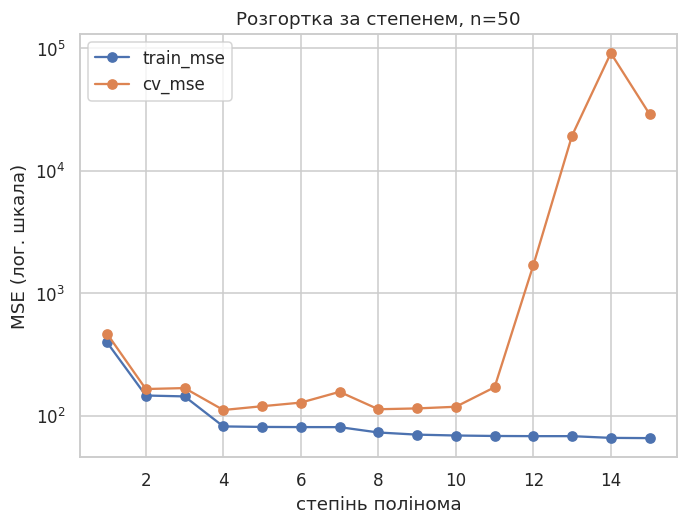

        train_mse      cv_mse         gap
degree                                   
1        397.9000    468.5000     70.6000
2        146.9000    165.9000     19.0000
3        144.4000    168.8000     24.4000
4         82.2000    111.9000     29.7000
5         81.4000    120.1000     38.7000
6         81.1000    128.5000     47.4000
7         81.1000    157.3000     76.3000
8         73.3000    113.5000     40.1000
9         70.4000    115.3000     44.8000
10        69.3000    118.9000     49.6000
11        68.7000    171.5000    102.8000
12        68.4000  1,699.1000  1,630.6000
13        68.4000 19,405.7000 19,337.3000
14        66.3000 91,266.8000 91,200.5000
15        66.0000 28,992.7000 28,926.8000

високі степені на тих самих 50 точках:
        train_mse   cv_mse
degree                    
20           57.6 1.88e+09
30           51.8 6.07e+13
40           63.7    4e+16
49             63 4.08e+16


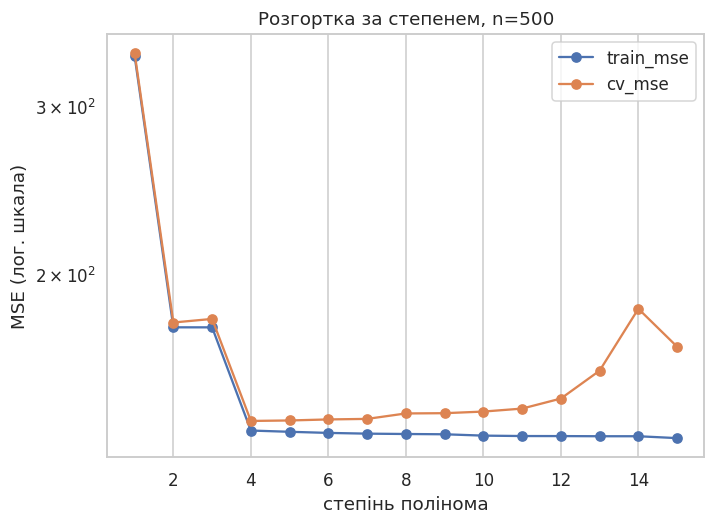

        train_mse   cv_mse
degree                    
1        339.2000 341.5000
2        176.1000 178.2000
3        176.1000 179.8000
4        137.3000 140.5000
5        136.9000 140.7000
6        136.5000 141.0000
7        136.3000 141.2000
8        136.1000 143.1000
9        136.1000 143.2000
10       135.6000 143.7000
11       135.5000 144.8000
12       135.5000 148.3000
13       135.4000 158.6000
14       135.4000 184.2000
15       134.8000 168.1000
найкращий degree: n=50 -> 4 | n=500 -> 4
n=50: перший degree після оптимуму з cv_mse > 1.2 x мінімум -> 7
n=500: перший degree після оптимуму з cv_mse > 1.2 x мінімум -> 14


In [15]:
# (a)/(b): графік тієї самої розгортки _sweep з Task 5 (50 точок, квартика + шум sd=12)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(_sweep.index, _sweep["train_mse"], marker="o", label="train_mse")
ax.plot(_sweep.index, _sweep["cv_mse"], marker="o", label="cv_mse")
ax.set_yscale("log")
ax.set_xlabel("степінь полінома")
ax.set_ylabel("MSE (лог. шкала)")
ax.set_title("Розгортка за степенем, n=50")
ax.legend()
plt.show()
print((_sweep.assign(gap=_sweep["cv_mse"] - _sweep["train_mse"])).round(1).to_string())

# (b) що відбувається з train_mse, коли degree наближається до n: 50 точок -> degree до 49
_extreme = degree_sweep(_x_poly, _y_poly, [20, 30, 40, 49], KFold(5, shuffle=True, random_state=SEED))
print("\nвисокі степені на тих самих 50 точках:")
print(_extreme.to_string(float_format=lambda v: f"{v:.3g}"))

# (c) той самий генератор, 500 точок
_rng500 = np.random.default_rng(SEED)
_x500 = _rng500.uniform(-3, 3, 500)
_y500 = (_x500 ** 4 - 3 * _x500 ** 2 + _x500 + 5) + _rng500.normal(0, 12.0, 500)
_sweep500 = degree_sweep(_x500, _y500, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(_sweep500.index, _sweep500["train_mse"], marker="o", label="train_mse")
ax.plot(_sweep500.index, _sweep500["cv_mse"], marker="o", label="cv_mse")
ax.set_yscale("log")
ax.set_xlabel("степінь полінома")
ax.set_ylabel("MSE (лог. шкала)")
ax.set_title("Розгортка за степенем, n=500")
ax.legend()
plt.show()
print(_sweep500.round(1).to_string())
print("найкращий degree: n=50 ->", _sweep["cv_mse"].idxmin(), "| n=500 ->", _sweep500["cv_mse"].idxmin())
for name, sw in (("n=50", _sweep), ("n=500", _sweep500)):
    worse = sw.index[(sw.index > sw["cv_mse"].idxmin()) & (sw["cv_mse"] > 1.2 * sw["cv_mse"].min())]
    print(f"{name}: перший degree після оптимуму з cv_mse > 1.2 x мінімум -> "
          f"{worse.min() if len(worse) else 'немає до 15'}")

**Your answer:**

Розгортка `_sweep` з Task 5: 50 точок, справжня функція — поліном 4-го степеня, шум sd = 12 (дисперсія шуму 144). Мінімум `cv_mse` = 111.9 при **degree = 4**.

**(a)** **Недонавчання — degree 1–3.** І `train_mse`, і `cv_mse` високі (при degree = 1: 398 і 468), і розрив між ними помірний: модель не може відтворити форму залежності навіть на навчальних даних. **Перенавчання — degree ≥ 5, різко з 11–12.** `train_mse` і далі спадає (81 → 66), а `cv_mse` росте: 120 при degree = 5, 157 при 7, 172 при 11, 1 699 при 12, 91 267 при 14. Розрив між кривими зростає з 30 при degree = 4 до десятків тисяч. Діагностичний сам розрив, а не якась одна крива. `train_mse` не зростає за побудовою, тож низька тренувальна помилка нічого не каже про узагальнення. А висока `cv_mse` сама не каже, чому вона висока. Обидві криві високі й близькі — недонавчання, модель треба ускладнити. `train_mse` низька, а `cv_mse` висока — перенавчання, модель треба спростити або дати більше даних. Діагнози протилежні, і розрізнити їх можна лише порівнюючи обидві криві.

**(b)** Теоретично, коли degree наближається до n − 1 = 49, `train_mse` прямує до **нуля**. Поліном з 50 коефіцієнтами може точно пройти через 50 точок з різними x (матриця Вандермонда оборотна), тобто запам'ятовує вибірку разом із шумом. `cv_mse` при цьому вибухає: між точками і за межами навчальних x такий поліном шалено коливається (явище Рунге). На практиці я прогнав degree 20, 30, 40, 49 на тих самих 50 точках: `cv_mse` сягає 1.9·10⁹ і 4·10¹⁶, а от `train_mse` **не** дійшла до нуля — вона застрягла на 52–64 і навіть трохи зросла. Причина чисельна: при |x| ≤ 3 стовпчик x⁴⁹ сягає ~10²³, матриця ознак стає вироджено обумовленою, і `LinearRegression` уже не може знайти точну інтерполяцію в арифметиці з рухомою комою. Тобто «train → 0» — властивість математики, а не комп'ютера; сирі степені x на такій висоті не працюють навіть як інструмент запам'ятовування.

**(c)** На 500 точках з тим самим генератором і тим самим шумом переможець той самий — **degree = 4** (`cv_mse` = 140.5, близько до дисперсії шуму 144). Але область перенавчання відсунулася дуже далеко. Критерій «`cv_mse` на 20% гірша за мінімум» спрацьовує при n = 50 уже на degree = 7, а при n = 500 — лише на degree = 14. Навіть degree = 12 при n = 500 дає 148, лише на 6% гірше за оптимум, тоді як при n = 50 на тому самому степені помилка в 15 разів більша. Розрив train/cv на 500 точках на degree 4–11 не перевищує 10. Загальне правило: складність моделі, яку можна собі дозволити, зростає з кількістю даних. Правильна складність визначається справжньою залежністю (тут 4-й степінь), але ціна зайвої гнучкості падає, коли точок більше: кожен зайвий параметр має менше свободи підігнатися під шум, бо його обмежує більше реального сигналу.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """
    param_grid = {
        "max_depth": list(depths),   # None -> дереву дозволено рости без обмеження глибини
                                       # (поки листки не стануть чистими) -> порівнюємо цей
                                       # крайній випадок з явно регуляризованими глибинами
        "criterion": list(criteria),
    }

    search = GridSearchCV(
        DecisionTreeClassifier(random_state=SEED),
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        refit=True,   # після завершення пошуку одразу перенавчає найкращу комбінацію
                       # параметрів на ВСІХ даних -> search сам стає готовою моделлю
    )
    search.fit(X, y)

    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search,
    }

In [17]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [18]:
# (a) таблиця CV-оцінки за max_depth і criterion — з того самого _tuned (iris), що в Task 6
res = pd.DataFrame(_tuned["search"].cv_results_)
res["max_depth"] = res["param_max_depth"].astype(object).where(res["param_max_depth"].notna(), "None")
table = res.pivot_table(index="max_depth", columns="param_criterion",
                        values="mean_test_score", aggfunc="first", sort=False)
print(table.round(4).to_string())
print("найкраще:", _tuned["best_depth"], _tuned["best_criterion"], round(_tuned["best_cv_score"], 4))

# (c) train accuracy при необмеженій глибині
full_tree = DecisionTreeClassifier(max_depth=None, random_state=SEED)
full_tree.fit(_X_iris, _y_iris)
print("\ntrain accuracy, max_depth=None:", full_tree.score(_X_iris, _y_iris))
print("фактична глибина, до якої дерево доросло само:", full_tree.get_depth(),
      " листків:", full_tree.get_n_leaves())
print("CV того самого необмеженого дерева:",
      round(cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean(), 4))
for leaf in (1, 5, 10):
    t = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=SEED).fit(_X_iris, _y_iris)
    print(f"min_samples_leaf={leaf:>2}: глибина {t.get_depth()}, листків {t.get_n_leaves()}, "
          f"CV {cross_val_score(DecisionTreeClassifier(min_samples_leaf=leaf, random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean():.4f}")

# (b) приклад, де gini і entropy обирають РІЗНІ розбиття: батьківський вузол (40, 40, 20)
def _gini(c):
    p = np.asarray(c, float) / np.sum(c); return 1 - np.sum(p ** 2)
def _entropy(c):
    p = np.asarray(c, float) / np.sum(c); p = p[p > 0]; return -np.sum(p * np.log2(p))
def _weighted(f, parts):
    n = sum(sum(p) for p in parts); return sum(sum(p) / n * f(p) for p in parts)
_splits = {"A: відрізати 5 чистих точок класу 3": [(0, 0, 5), (40, 40, 15)],
           "B: увесь клас 3 — праворуч":          [(20, 20, 0), (20, 20, 20)]}
for name, parts in _splits.items():
    print(f"{name:38} gini={_weighted(_gini, parts):.4f}  entropy={_weighted(_entropy, parts):.4f}")

param_criterion   gini  entropy
max_depth                      
1               0.6667   0.6667
2               0.9200   0.9200
3               0.9200   0.9200
4               0.9333   0.9333
5               0.9333   0.9333
6               0.9333   0.9333
8               0.9333   0.9333
10              0.9333   0.9333
None            0.9333   0.9333
найкраще: 4 gini 0.9333

train accuracy, max_depth=None: 1.0
фактична глибина, до якої дерево доросло само: 5  листків: 9
CV того самого необмеженого дерева: 0.9333
min_samples_leaf= 1: глибина 5, листків 9, CV 0.9333
min_samples_leaf= 5: глибина 4, листків 6, CV 0.9200
min_samples_leaf=10: глибина 4, листків 6, CV 0.9200
A: відрізати 5 чистих точок класу 3    gini=0.5895  entropy=1.3978
B: увесь клас 3 — праворуч             gini=0.6000  entropy=1.3510


**Your answer:**

**(a)** CV-оцінка `_tuned` (iris, 5 фолдів):

| max_depth | gini | entropy |
|---|---|---|
| 1 | 0.6667 | 0.6667 |
| 2 | 0.9200 | 0.9200 |
| 3 | 0.9200 | 0.9200 |
| 4 | 0.9333 | 0.9333 |
| 5, 6, 8, 10, None | 0.9333 | 0.9333 |

**Недонавчання — мала глибина.** При max_depth = 1 дерево має два листки й не може розділити три класи (0.667). При 2–3 точність 0.92, і повністю недонавчання закінчується на **глибині 4** (0.9333) — вона й обрана. **Перенавчання — велика глибина**, але на iris воно в CV не проявляється: при глибинах 5–10 і `None` оцінка лишається 0.9333. Причина видна в (c): необмежене дерево саме зупиняється на глибині 5 (9 листків), бо листки стають чистими. Обмеження `max_depth ≥ 5` просто не активне, і дерев, глибших за 5, на цих даних не існує. Тобто перенавчання «починалося б» після глибини 4: глибше дерево підганяє кілька прикордонних точок versicolor/virginica, нічого не вигравши в CV. Але на 150 добре розділених точках воно не встигає нашкодити.

**(b)** Gini-домішка = 1 − Σpᵢ² — ймовірність, що дві випадково взяті з вузла точки належать до різних класів. Ентропія = −Σpᵢ·log₂pᵢ — середня кількість біт, потрібна, щоб назвати клас випадкової точки. Обидві — угнуті функції розподілу класів: нуль для чистого вузла, максимум для рівномірного. Вони вимірюють одне й те саме, неоднорідність вузла, двома «лінійками» майже однакової форми, тож майже завжди однаково ранжують кандидатів на розбиття. На iris вони збігаються на кожній глибині до четвертого знака. Розійтися вони можуть, коли порівнюються розбиття різного характеру. Я побудував такий приклад (вивід вище): батьківський вузол (40, 40, 20). Розбиття A відрізає 5 чистих точок класу 3: gini = **0.5895**, entropy = **1.3978**. Розбиття B відправляє весь клас 3 праворуч, (20, 20, 0) | (20, 20, 20): gini = **0.6000**, entropy = **1.3510**. Gini віддає перевагу A, ентропія — B. Ентропія сильніше винагороджує повне очищення лівого вузла від класу 3, а gini — ізоляцію маленької чистої групи при майже незміненому великому вузлі.

**(c)** Training accuracy необмеженого дерева = **1.0**. Це число неінформативне, бо дерево без обмежень росте, доки кожен листок не стане чистим, тобто завжди «вивчить» навчальні дані напам'ять незалежно від того, чи є в них закономірність. Його CV-оцінка (0.9333) при цьому не краща за дерево глибини 4. Той самий ефект з іншого боку обмежує **`min_samples_leaf`** (Practice 3 §8.3). `max_depth` обмежує довжину шляху від кореня, а `min_samples_leaf` забороняє листки, менші за задану кількість точок. У виводі: з `min_samples_leaf = 5` дерево має 6 листків і глибину 4 замість 9 листків і глибини 5.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
        'cv_scores'         a 1-D array of mean CV accuracy, one per k
        'best_k_cv'         the k chosen by cross-validation
        'test_accuracy'     the honest test accuracy of that k
        'best_k_peeking'    the k that maximises test accuracy
        'peeking_accuracy'  that k's test accuracy (an optimistic number)
    """
    # крок 1: підбір k -> дивимось ЛИШЕ на тренувальні дані через CV;
    # X_test/y_test тут навіть не згадуються
    cv_scores = []
    for k in k_values:
        pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
        scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
        cv_scores.append(scores.mean())
    cv_scores = np.array(cv_scores)

    # np.argmax повертає ПЕРШИЙ індекс максимуму -> якщо k_values впорядковані
    # за зростанням, нічия автоматично вирішується на користь найменшого
    # (найпростішого) k, як і вимагає умова
    best_idx_cv = int(np.argmax(cv_scores))
    best_k_cv = k_values[best_idx_cv]

    # крок 2: ЧЕСНА фінальна перевірка — одне перенавчання на всіх train,
    # один-єдиний прогін по test. Тестова вибірка жодного разу не впливала
    # на вибір k, тому це число можна довіряти як оцінку узагальнення
    honest_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k_cv))
    honest_pipe.fit(X_train, y_train)
    test_accuracy = float(honest_pipe.score(X_test, y_test))

    # для порівняння: що було б, якби ми (неправильно) обирали k за
    # найкращим результатом ПРЯМО на test -> це і є "підглядання"
    peeking_scores = []
    for k in k_values:
        pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
        pipe.fit(X_train, y_train)
        peeking_scores.append(pipe.score(X_test, y_test))
    peeking_scores = np.array(peeking_scores)

    best_idx_peeking = int(np.argmax(peeking_scores))
    best_k_peeking = k_values[best_idx_peeking]
    peeking_accuracy = float(peeking_scores[best_idx_peeking])

    return {
        "cv_scores": cv_scores,
        "best_k_cv": best_k_cv,
        "test_accuracy": test_accuracy,
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": peeking_accuracy,  # завжди >= test_accuracy — це і є ціна "підглядання"
    }

In [20]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

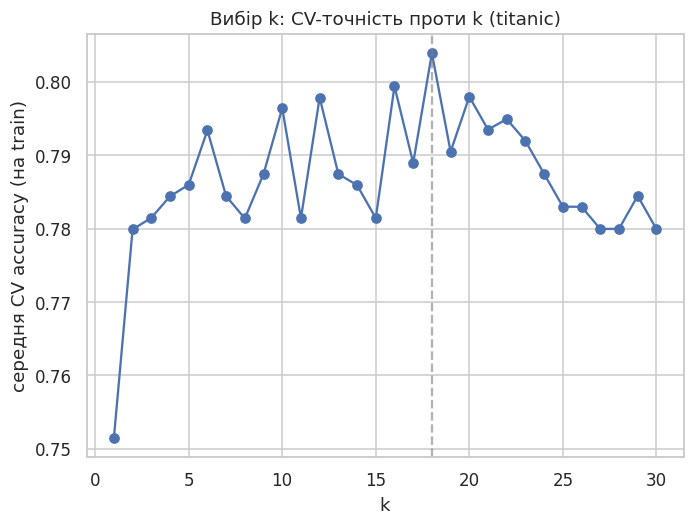

cv_scores при k=1, 5, 18, 30: [0.7515, 0.786, 0.8039, 0.78]
k=  1: train acc = 0.9760  CV acc = 0.7515  test acc = 0.7803
   (групи однакових рядків ознак з різними мітками в train: 12)
k=668: train acc = 0.6168  test acc = 0.6143  (CV тут неможлива: k більше за розмір тренувальної частини фолда)
частка мажоритарного класу (не вижив) у train: 0.6168, у test: 0.6143

k=1..30 : CV-k= 18 test=0.8206 | peeking k= 25 test=0.8520 | зсув +0.0314
k=1..200: CV-k= 18 test=0.8206 | peeking k= 25 test=0.8520 | зсув +0.0314
test_size=0.1: n_train=801 n_test=90 best_k=18 чесна test accuracy=0.8333 (± 0.0393 станд. похибка)
test_size=0.25: n_train=668 n_test=223 best_k=18 чесна test accuracy=0.8206 (± 0.0257 станд. похибка)
test_size=0.4: n_train=534 n_test=357 best_k= 8 чесна test accuracy=0.8095 (± 0.0208 станд. похибка)

без stratify, test_size=0.1, 20 seed: частка виживших у test від 0.300 до 0.456 (у всій вибірці 0.384)


In [21]:
# Ті самі дані й спліт, що в Task 7 (titanic, 6 ознак), і той самий результат _sel
k_values = list(range(1, 31))
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_values, _sel["cv_scores"], marker="o")
ax.axvline(_sel["best_k_cv"], color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("k")
ax.set_ylabel("середня CV accuracy (на train)")
ax.set_title("Вибір k: CV-точність проти k (titanic)")
plt.show()
print("cv_scores при k=1, 5, 18, 30:", [round(float(_sel["cv_scores"][k - 1]), 4) for k in (1, 5, 18, 30)])

# крайні випадки
p1 = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)).fit(_Xk_tr, _yk_tr)
print(f"k=  1: train acc = {p1.score(_Xk_tr, _yk_tr):.4f}  CV acc = {_sel['cv_scores'][0]:.4f}  "
      f"test acc = {p1.score(_Xk_te, _yk_te):.4f}")
_dups = pd.DataFrame(_Xk_tr).assign(y=_yk_tr).groupby(list(range(_Xk_tr.shape[1])))["y"].nunique()
print(f"   (групи однакових рядків ознак з різними мітками в train: {(_dups > 1).sum()})")
kmax = len(_Xk_tr)
pm = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=kmax)).fit(_Xk_tr, _yk_tr)
print(f"k={kmax}: train acc = {pm.score(_Xk_tr, _yk_tr):.4f}  test acc = {pm.score(_Xk_te, _yk_te):.4f}  "
      f"(CV тут неможлива: k більше за розмір тренувальної частини фолда)")
print(f"частка мажоритарного класу (не вижив) у train: {1 - _yk_tr.mean():.4f}, у test: {1 - _yk_te.mean():.4f}")

# (b) k=1..200 замість k=1..30
_sel200 = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, list(range(1, 201)), _k_cv)
print(f"\nk=1..30 : CV-k={_sel['best_k_cv']:>3} test={_sel['test_accuracy']:.4f} | "
      f"peeking k={_sel['best_k_peeking']:>3} test={_sel['peeking_accuracy']:.4f} | "
      f"зсув {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print(f"k=1..200: CV-k={_sel200['best_k_cv']:>3} test={_sel200['test_accuracy']:.4f} | "
      f"peeking k={_sel200['best_k_peeking']:>3} test={_sel200['peeking_accuracy']:.4f} | "
      f"зсув {_sel200['peeking_accuracy'] - _sel200['test_accuracy']:+.4f}")

# (c) test_size 0.1 / 0.25 / 0.4, той самий seed
for ts in (0.1, 0.25, 0.4):
    Xtr, Xte, ytr, yte = train_test_split(_X_knn, _y_knn, test_size=ts, random_state=SEED, stratify=_y_knn)
    r = honest_k_selection(Xtr, ytr, Xte, yte, k_values, _k_cv)
    se = np.sqrt(r["test_accuracy"] * (1 - r["test_accuracy"]) / len(yte))
    print(f"test_size={ts}: n_train={len(ytr)} n_test={len(yte)} best_k={r['best_k_cv']:>2} "
          f"чесна test accuracy={r['test_accuracy']:.4f} (± {se:.4f} станд. похибка)")

# що захищає stratify: частка виживших у test без стратифікації для кількох seed
_shares = [train_test_split(_X_knn, _y_knn, test_size=0.1, random_state=s)[3].mean() for s in range(20)]
print(f"\nбез stratify, test_size=0.1, 20 seed: частка виживших у test від {min(_shares):.3f} до {max(_shares):.3f} "
      f"(у всій вибірці {_y_knn.mean():.3f})")

**Your answer:**

**(a)** Дані — ті самі, що в Task 7: Titanic, 6 ознак, 668 рядків у train. CV-точність при k = 1 — 0.752, вона швидко росте до максимуму **0.804 при k = 18**, а до k = 30 знову трохи спадає (0.780). **k = 1 — перенавчання.** Кожна точка класифікується за одним найближчим сусідом, межа рішення обходить кожну тренувальну точку, тож модель запам'ятовує шум. Training accuracy майже ідеальна — **0.976**, а не рівно 1.0 лише тому, що в train є 12 груп однакових рядків ознак з різними мітками, яких жодна модель не розрізнить. CV-точність при цьому 0.752, test — 0.780. **k = len(X_train) = 668 — недонавчання в крайній формі.** Кожна точка «голосує» всією вибіркою, тож прогноз завжди один — мажоритарний клас «не вижив». Training accuracy = **0.6168** і test = **0.6143** — рівно частки мажоритарного класу в train і test. Модель вироджується в baseline з Task 3.

**(b)** Число з підгляданням завищене, бо воно є **максимумом з багатьох шумних вимірювань**. Для кожного k test accuracy = справжня якість + випадкова похибка конкретних 223 тестових рядків (стандартна похибка ≈ 0.026). Обираючи k з найкращою test accuracy, ми обираємо не лише найкращу модель, а й найбільш вдалу випадкову похибку. Максимум з 30 шумних чисел систематично вищий за їхнє справжнє значення. У мене чесна процедура дала k = 18 і **0.8206**, а підглядання — k = 25 і **0.8520**, завищення **+3.1 в.п.** Я очікував, що зі збільшенням кількості кандидатів (k = 1…200) завищення зросте: максимум з більшої кількості шумних величин у середньому більший. Перевірка показала **те саме +3.1 в.п.**: CV знову обрала k = 18, а найкращим на test лишився k = 25. Жоден k від 31 до 200 не перевершив 0.8520, бо великі k вже систематично гірші (зміщення до мажоритарного класу), і їхній шум не компенсує цієї втрати. Тобто ефект росте з кількістю кандидатів лише тоді, коли нові кандидати приблизно так само добрі, як старі. Тут вони гірші, тож максимум не змінився.

**(c)** Чесна test accuracy за того самого seed:

| test_size | n_train | n_test | обраний k | test accuracy | ± станд. похибка |
|---|---|---|---|---|---|
| 0.10 | 801 | 90 | 18 | 0.8333 | 0.039 |
| 0.25 | 668 | 223 | 18 | 0.8206 | 0.026 |
| 0.40 | 534 | 357 | 8 | 0.8095 | 0.021 |

Зі збільшенням test **покращується** надійність фінальної оцінки: стандартна похибка падає з 0.039 до 0.021, тобто 0.83 на 90 рядках — це «десь від 0.79 до 0.87», а 0.81 на 357 рядках відома значно точніше. **Погіршується** модель, яку ми оцінюємо: на 534 рядках train CV обрала вже інший k (8 замість 18), і точність трохи нижча. Великий test дає точну оцінку трохи гіршої моделі, малий — неточну оцінку трохи кращої. Різниця між трьома числами (0.81–0.83) менша за похибку найменшого test, тож з них не можна сказати, що якийсь поділ «кращий».

`stratify=` захищає від того, щоб пропорції класів у train і test (і в кожному фолді) випадково відрізнялися від пропорцій у всій вибірці (Practice 3 §5.3). Я перевірив без стратифікації при test_size = 0.1 і 20 різних seed: частка тих, хто вижив, у test коливається **від 0.300 до 0.456** при 0.384 у всій вибірці. Така різниця сама по собі зсуває accuracy (особливо в baseline-моделі, як при k = 668), і ця зміна не має стосунку до якості моделі. Зі `stratify=y_knn` частка в test фіксована.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [22]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """
    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    mu_x, mu_y = scaler.mean_        # середні, використані для z1, z2
    s_x, s_y = scaler.scale_         # стандартні відхилення, використані для z1, z2
    w1, w2 = svc.coef_[0]            # ваги межі у МАСШТАБОВАНОМУ просторі
    b = svc.intercept_[0]

    if w2 == 0:
        # межа w1*z1 + b = 0 не залежить від z2 -> у вихідних координатах
        # це вертикальна пряма x = const, її не можна записати як y = slope*x + intercept
        raise ValueError("w2 дорівнює нулю: межа вертикальна, форми y = slope*x + intercept не існує")

    # підставляємо z1 = (x-mu_x)/s_x, z2 = (y-mu_y)/s_y у w1*z1 + w2*z2 + b = 0
    # і розв'язуємо відносно y:
    #   y = mu_y - (w1*s_y)/(w2*s_x) * (x - mu_x) - (b*s_y)/w2
    slope = -(w1 * s_y) / (w2 * s_x)
    intercept = mu_y - slope * mu_x - (b * s_y) / w2

    return (float(slope), float(intercept))

In [23]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.40e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

=== лінійне ядро ===
C=0.001  опорних векторів=600  margin=4.9368  train_acc=0.8350
C=1      опорних векторів=74   margin=0.4146  train_acc=0.9717
C=1000   опорних векторів=46   margin=0.2189  train_acc=0.9733

=== лінійне ядро, CV ===
C=0.001  cv_acc=0.8317
C=1      cv_acc=0.9717
C=1000   cv_acc=0.9717

=== rbf ядро, C=1 ===
gamma=0.01  cv_acc=0.9650  train_acc=0.9600  опорних векторів=284
gamma=1     cv_acc=0.9683  train_acc=0.9733  опорних векторів=86
gamma=100   cv_acc=0.9550  train_acc=0.9850  опорних векторів=487


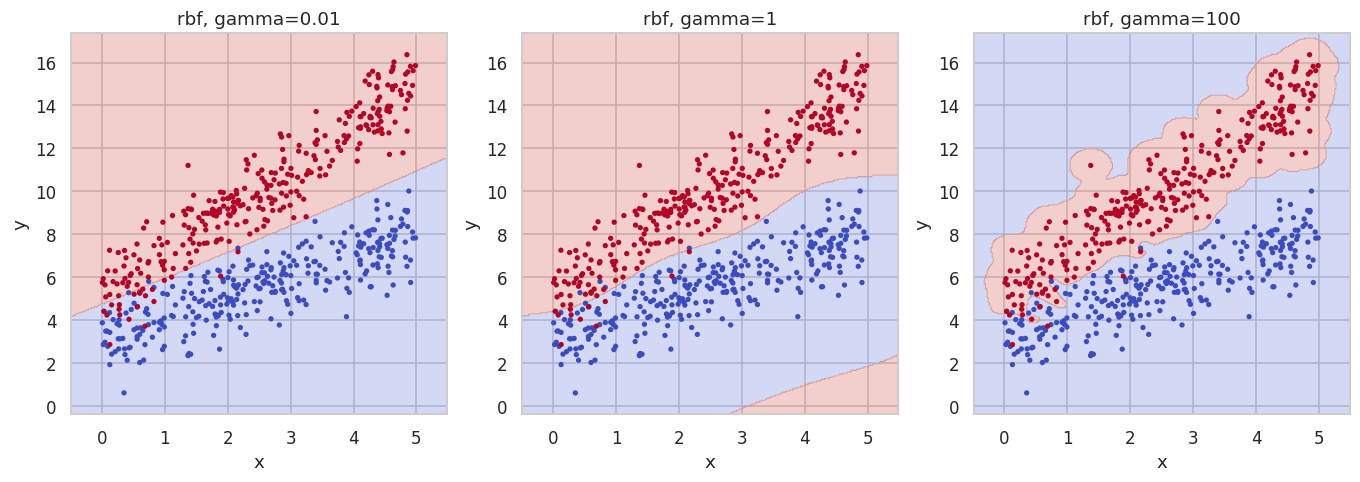


linear, C=1: cv_acc = 0.9717 ± 0.0042 (станд. похибка)
найкраще rbf з 16 комбінацій: cv_acc = 0.9750, C = 10, gamma = 0.01


In [24]:
# Ті самі дані, що в Task 8: _X_two, _y_two (дві прямі з шумом, 600 точок)
print("=== лінійне ядро ===")
for C_ in (0.001, 1, 1000):
    pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C_))
    pipe.fit(_X_two, _y_two)
    svc = pipe.named_steps["svc"]
    margin = 2 / np.linalg.norm(svc.coef_[0])
    print(f"C={C_:<6} опорних векторів={svc.support_.shape[0]:<4} margin={margin:.4f}  "
          f"train_acc={pipe.score(_X_two, _y_two):.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n=== лінійне ядро, CV ===")
for C_ in (0.001, 1, 1000):
    acc = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="linear", C=C_)),
                          _X_two, _y_two, cv=cv).mean()
    print(f"C={C_:<6} cv_acc={acc:.4f}")

# (b) rbf, різні gamma, C=1
print("\n=== rbf ядро, C=1 ===")
for gamma in (0.01, 1, 100):
    pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=gamma))
    cv_acc = cross_val_score(pipe, _X_two, _y_two, cv=cv).mean()
    pipe.fit(_X_two, _y_two)
    print(f"gamma={gamma:<5} cv_acc={cv_acc:.4f}  train_acc={pipe.score(_X_two, _y_two):.4f}  "
          f"опорних векторів={pipe.named_steps['svc'].support_.shape[0]}")

# рисунок меж рішення при трьох gamma
xx, yy = np.meshgrid(np.linspace(_X_two[:, 0].min() - 0.5, _X_two[:, 0].max() + 0.5, 300),
                     np.linspace(_X_two[:, 1].min() - 1, _X_two[:, 1].max() + 1, 300))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, gamma in zip(axes, (0.01, 1, 100)):
    pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=gamma)).fit(_X_two, _y_two)
    zz = pipe.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(_X_two[:, 0], _X_two[:, 1], c=_y_two, s=6, cmap="coolwarm")
    ax.set_title(f"rbf, gamma={gamma}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.show()

# (c) лінійне проти найкращого rbf, обидва за CV
lin_cv = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="linear", C=1)),
                         _X_two, _y_two, cv=cv)
best = max(
    ((cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="rbf", C=C_, gamma=g)),
                      _X_two, _y_two, cv=cv).mean(), C_, g)
     for C_ in (0.1, 1, 10, 100) for g in (0.01, 0.1, 1, 10)),
    key=lambda t: t[0],
)
print(f"\nlinear, C=1: cv_acc = {lin_cv.mean():.4f} ± {lin_cv.std(ddof=1) / np.sqrt(5):.4f} (станд. похибка)")
print(f"найкраще rbf з 16 комбінацій: cv_acc = {best[0]:.4f}, C = {best[1]}, gamma = {best[2]}")

**Your answer:**

Дані — ті самі дві прямі з шумом із Task 8 (`_X_two`, 600 точок).

**(a)**

| C | опорних векторів | margin (2/‖w‖) | train acc | CV acc |
|---|---|---|---|---|
| 0.001 | 600 | 4.94 | 0.835 | 0.832 |
| 1 | 74 | 0.41 | 0.972 | 0.972 |
| 1000 | 46 | 0.22 | 0.973 | 0.972 |

**Мале C — недонавчання.** Штраф за порушення межі майже нульовий, тож SVM обирає максимально широкий margin (4.94) і дозволяє порушувати його всім точкам. **Усі 600 точок** стають опорними векторами, і межа розташована погано: train і CV лише 0.83. **Велике C — напрям перенавчання.** Кожне порушення штрафується дуже сильно, margin стискається до 0.22, і межу визначають 46 найближчих, частково шумових точок. Train accuracy зростає (0.973), а CV не покращується (0.972). На цих даних, які майже лінійно розділені, вузький margin не встигає нашкодити, але вже нічого й не дає. C керує компромісом між шириною margin і штрафом за порушення: C → 0 дає найширший margin ціною помилок, C → ∞ — найвужчий margin, що обслуговує кожну прикордонну точку.

**(b)** RBF, C = 1:

| gamma | CV acc | train acc | опорних векторів |
|---|---|---|---|
| 0.01 | 0.965 | 0.960 | 284 |
| 1 | 0.968 | 0.973 | 86 |
| 100 | 0.955 | 0.985 | 487 |

gamma — це обернений «радіус дії» однієї тренувальної точки: її вплив спадає як exp(−gamma·‖x − x′‖²). При **gamma = 0.01** кожна точка діє на великій відстані, рішення в будь-якому місці формують сотні точок разом, і межа на рисунку майже пряма — це напрям недонавчання. При **gamma = 100** вплив точки згасає вже поруч із нею, тож межа перетворюється на тісну «оболонку» навколо червоних точок, а все поза нею автоматично стає синім. Цей екстремум **запам'ятовує**: train accuracy найвища (0.985), опорними стають 487 з 600 точок (кожна відповідає сама за себе), а CV найнижча (0.955). Проміжна gamma = 1 дає злегка вигнуту межу, але поза даними (правий нижній кут рисунка) вже з'являється хибна червона зона: гнучкість, якої задача не потребує.

**(c)** Лінійне ядро (C = 1): **CV = 0.9717 ± 0.0042** (стандартна похибка між фолдами). Найкраще RBF серед 16 комбінацій C × gamma: **CV = 0.9750** (C = 10, gamma = 0.01). Різниця 0.33 в.п. менша за одну стандартну похибку — не значуща. До того ж ця «перевага» — максимум з 16 спроб проти однієї для лінійного ядра, тобто вона ще й завищена тим самим ефектом, що в Питанні 5(b). Показово, що перемогла найменша gamma, тобто найбільш лінійна конфігурація RBF: воно просто навчилося поводитися як пряма. Загальний принцип: модель, гнучкіша за те, чого вимагає задача, не зменшує зміщення (нелінійної структури, яку можна вловити, немає), але додає дисперсію, гіперпараметри для підбору й артефакти поза даними. Починати слід з найпростішої моделі, здатної описати задачу, і ускладнювати лише тоді, коли є конкретний доказ, що проста модель недостатня.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [25]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
    rows = []
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        labels = kmeans.fit_predict(X)

        # inertia: сума квадратів відстаней точок до їхнього центроїда ->
        # монотонно спадає зі зростанням k майже завжди (більше кластерів
        # завжди може лише зменшити цю суму), тому сама по собі НЕ визначає
        # найкраще k без додаткового критерію (напр. "лікоть")
        inertia = float(kmeans.inertia_)

        # silhouette: наскільки точка ближча до свого кластера, ніж до
        # найближчого ЧУЖОГО -> в діапазоні [-1, 1], НЕ монотонна за k,
        # тому має справжній максимум, придатний для вибору k
        silhouette = float(silhouette_score(X, labels))

        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED)
        gmm.fit(X)

        # bic/aic: правдоподібність моделі, оштрафована за кількість
        # параметрів (bic карає сильніше при більшій вибірці) -> на відміну
        # від inertia, ці штрафи дозволяють кривій мати мінімум, а не
        # монотонно спадати зі зростанням k
        bic = float(gmm.bic(X))
        aic = float(gmm.aic(X))

        rows.append({"k": k, "inertia": inertia, "silhouette": silhouette, "bic": bic, "aic": aic})

    return pd.DataFrame(rows).set_index("k")[["inertia", "silhouette", "bic", "aic"]]

In [26]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
k                                             
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [27]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


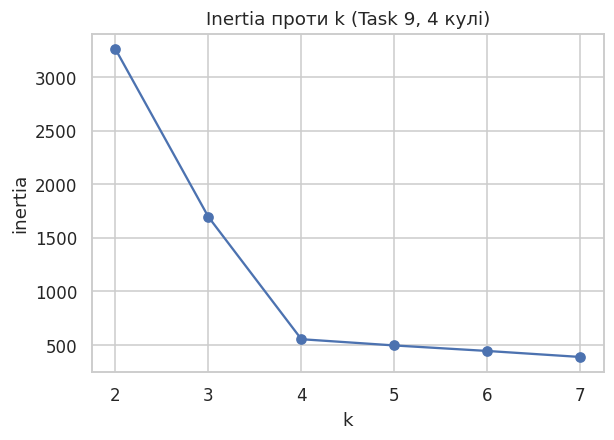

зменшення inertia при переході до k: {3: 1566.4, 4: 1141.2, 5: 58.2, 6: 51.5, 7: 56.1}
     inertia  silhouette        bic        aic
k                                             
2 7,175.0015      0.5161 8,512.4188 8,459.5924
3 4,690.2507      0.4231 8,410.6689 8,329.0282
4 3,470.1581      0.4282 8,451.9986 8,341.5436
5 2,822.5206      0.4039 8,490.5456 8,351.2761
6 2,355.3401      0.3660 8,526.4194 8,358.3356
k за silhouette (max): 2
k за BIC (min): 3
n_init=1: min 4690.2506622636265 max 4692.743287289886 std 0.8562631488945858
n_init=10: 4690.2506622636265
full ARI = 0.6406735533262173
tied ARI = 0.44931062708180836
diag ARI = 0.43623232973880294
spherical ARI = 0.4526646248225033
k-means ARI = 0.46063418514166954


In [28]:
# (a) inertia проти k — на чотирьох круглих кулях з Task 9 (_scores)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(_scores.index, _scores["inertia"], marker="o")
ax.set_xlabel("k"); ax.set_ylabel("inertia"); ax.set_title("Inertia проти k (Task 9, 4 кулі)")
plt.show()
_drops = -_scores["inertia"].diff()
print("зменшення inertia при переході до k:", _drops.dropna().round(1).to_dict())

# (b)
table = cluster_selection(X_hard, range(2, 7))
print(table)
print("k за silhouette (max):", table["silhouette"].idxmax())
print("k за BIC (min):", table["bic"].idxmin())

# (c)
inertias = []
for rs in range(10):
    km = KMeans(n_clusters=3, n_init=1, random_state=rs)
    km.fit(X_hard)
    inertias.append(km.inertia_)
inertias = np.array(inertias)
print("n_init=1: min", inertias.min(), "max", inertias.max(), "std", inertias.std())
print("n_init=10:", KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_hard).inertia_)

# (d)
for cov_type in ("full", "tied", "diag", "spherical"):
    labels = GaussianMixture(n_components=3, covariance_type=cov_type,
                              random_state=SEED).fit_predict(X_hard)
    print(cov_type, "ARI =", adjusted_rand_score(y_hard, labels))
print("k-means ARI =", adjusted_rand_score(y_hard, KMeans(n_clusters=3, n_init=10,
                                                            random_state=SEED).fit_predict(X_hard)))

**Your answer:**

(a) На чотирьох круглих кулях з Task 9 inertia падає так: 3261 → 1695 → 553 → 495 → 444 → 388 для k = 2…7. Inertia монотонно спадає зі зростанням k і в межі (k=n, кожна точка — окремий кластер) дорівнює нулю — тобто пряма мінімізація inertia завжди "виграє" від збільшення k, без жодного штрафу за складність, тож обрати k таким чином неможливо. "Лікоть" мав би позначати точку, де темп спадання різко сповільнюється — де додаткові кластери вже не відокремлюють справді різні групи, а лише дроблять уже знайдені. На моєму графіку лікоть однозначний: переходи до k = 3 і k = 4 зменшують inertia на 1566 і 1141, а кожен наступний — лише на 52–58, тобто в 20 разів менше. Тут я впевнений у k = 4, бо дані — чотири добре розділені круглі кулі, і silhouette та BIC з Task 9 теж обрали 4. Але впевненість — властивість цих даних, а не методу. Сам лікоть не має порогу: на даних з перекриттям, як у (b), inertia для k = 2…6 спадає плавно (7175 → 4690 → 3470 → 2823 → 2355), і «злам» там — радше суб'єктивний вибір, ніж факт.

(b) На складніших даних (три нахилені компоненти, дві з яких перекриваються) Silhouette обирає k=2 (0.5161), BIC (і AIC) — k=3 (8410.67, мінімум). Правильна відповідь — k=3, бо дані згенеровані рівно з трьох компонент. Silhouette дає k=2 тому, що вона рахує (b-a)/max(a,b) для ЖОРСТКОГО розбиття k-means: дві компоненти перекриваються й нахилені (не сферичні), тож при k=3 k-means змушений провести межу прямо крізь зону їхнього перекриття — точки там отримують низький silhouette, що тягне середнє вниз. При k=2 ці дві компоненти просто об'єднуються в один (нерівний, але цілісний) кластер, а третя лишається далеко й чітко відокремленою — середня внутрішньокластерна відстань хоч і зростає, та все одно значно менша за відстань до третього кластера, тож середній silhouette виходить вищим ціною втрати реальної структури. Silhouette — чисто геометричний критерій над жорстким розбиттям: він не "знає" про справжню породжувальну модель, лише оцінює, наскільки чисто розбиття виглядає у евклідовому просторі. BIC оцінює правдоподібність повної (full-covariance) гаусової суміші, яка МОЖЕ представити нахилені перекривні еліпси, і тому коректно "бачить", що модель із трьома компонентами пояснює розподіл даних краще — навіть якщо геометрично вони не виглядають ідеально розділеними.

(c) При n_init=1 (k=3) inertia коливається від 4690.25 до 4692.74 залежно від random_state (std≈0.856) — невеликий, але реальний розкид: різні випадкові стартові центроїди інколи потрапляють у трохи гірший локальний мінімум невипуклої цільової функції k-means. n_init=10 дав 4690.2507 — точно збігається з найкращим (мінімальним) значенням серед одиночних запусків, тобто на цих даних 10 перезапусків гарантовано знайшли справжній оптимум. n_init — це кількість повністю незалежних перезапусків усього алгоритму (з різних випадкових ініціалізацій), з яких зберігається результат із найменшою inertia — захист від невдалого потрапляння в локальний мінімум одного окремого запуску. init='k-means++' змінює САМ спосіб вибору стартових центроїдів: замість рівномірно випадкових k точок, кожен наступний центроїд обирається з імовірністю, пропорційною квадрату відстані до вже обраних — це розсіює старт по даних і дає швидшу, надійнішу збіжність навіть при малому n_init, порівняно з init='random'.

(d) ARI за covariance_type: full=0.6407 (найкращий), tied=0.4493, diag=0.4362, spherical=0.4527; k-means (той самий k=3): 0.4606.

full — кожна компонента отримує повністю довільну власну коваріацію (будь-яка форма, розмір, нахил); саме так дані й згенеровані, тож це припущення відповідає дійсності найкраще. tied — усі компоненти ДІЛЯТЬ ОДНУ спільну коваріацію (та сама форма й нахил для всіх, різняться лише центри) — а тут форми різні. diag — власна коваріація на компоненту, але лише ДІАГОНАЛЬНА (без нахилу, осі еліпса вирівняні за координатними осями) — не може представити повернуті еліпси взагалі. spherical — найжорсткіше: кожна компонента ідеально кругла, різниться лише розміром. Саме spherical (0.4527) найближче відтворює власну поведінку k-means (0.4606) — це не випадково: k-means, мінімізуючи суму квадратів евклідових відстаней до центроїдів, неявно припускає круглі, приблизно однаково розподілені кластери — те саме припущення, що й covariance_type='spherical'.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

baseline RMSE=180.77±1.52 R2=-0.0006±0.0005
ridge  RMSE=102.91±2.12 R2=0.6756±0.0141
knn    RMSE=110.48±1.63 R2=0.6262±0.0113
rf     RMSE=66.49±0.70 R2=0.8646±0.0027
ridge  out-of-fold на dev: мінімальний прогноз -188.9, від'ємних 1411 з 13903 (10.1%)
rf     out-of-fold на dev: мінімальний прогноз 4.3, від'ємних 0 з 13903 (0.0%)
best params: {'model__max_depth': 20, 'model__min_samples_leaf': 1}  best CV RMSE: 60.40263646379211
TEST RMSE: 61.05729529892612
TEST MAE: 39.779148175259095
TEST R2: 0.8896468958776259


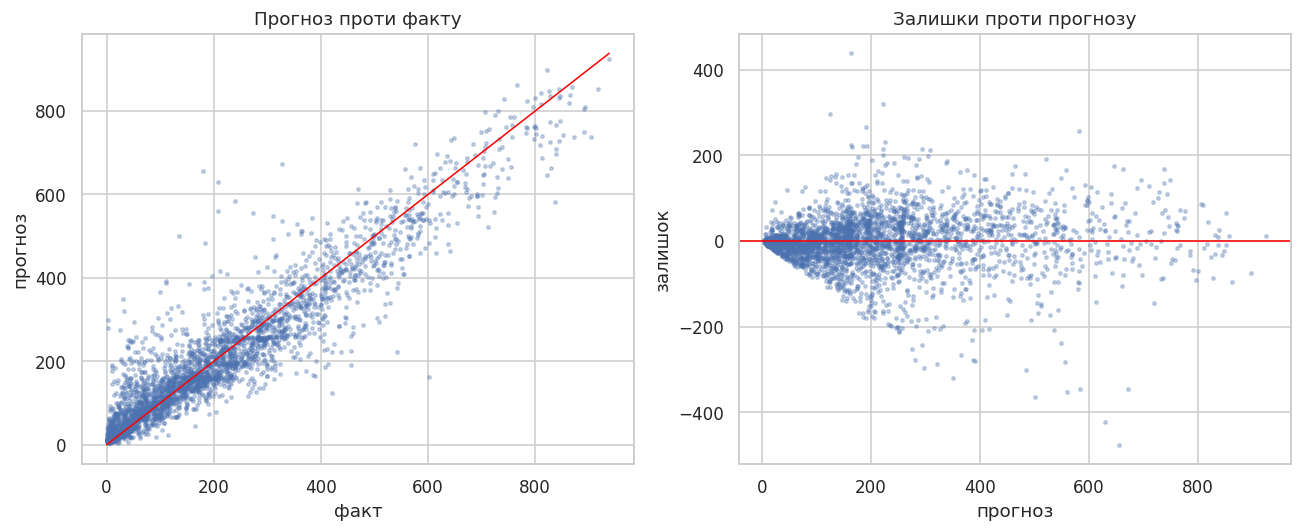

мінімальний прогноз (rf): 3.28  від'ємних прогнозів: 0
середній |залишок| за квартилями прогнозу:
(3.281, 62.906]      11.2500
(62.906, 157.053]    34.3000
(157.053, 267.211]   52.3100
(267.211, 925.252]   61.2600
dtype: float64

найбільший середній |залишок| (година, тип дня):
workingday  hr
1           0    94.3000
0           12   86.0000
            0    73.1000
            13   72.9000
1           18   70.1000
            17   66.7000
Name: abs_res, dtype: float64

середній |залишок| 0-5 год: 26.2 | робочі 7-9 і 16-19 год: 55.7
one-hot, drop='first' (обрана)   CV RMSE на dev = 60.40 ± 0.84
one-hot без drop                 CV RMSE на dev = 57.66 ± 0.67
hr/mnth/weekday як цілі числа    CV RMSE на dev = 45.93 ± 1.76


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# bikes і SEED — ті самі, що в Setup
from sklearn.model_selection import cross_val_predict

# ============================================================
# 1. Підготовка ознак
# ============================================================
target = "cnt"

# casual + registered = cnt ТОЧНО (перевірено: виконується для всіх рядків) ->
# на момент прогнозу нової години жодне з цих двох чисел ще не існує саме
# тому, що вони самі є складовими того результату, який прогнозується
drop_cols = [
    "instant",   # порядковий номер рядка -> нуль інформації понад дату+годину
    "dteday",    # надлишкова після розкладання на yr/mnth/weekday/hr
    "season",    # кореляція з mnth = 0.83 -> та сама сезонність, записана вдруге
    "atemp",     # кореляція з temp = 0.988 -> практично дублікат
    "casual", "registered",  # витік, пояснено вище
]

numeric_features = ["temp", "hum", "windspeed",  # неперервні фізичні виміри -> масштабувати
                     "weathersit",                # єдина зі справжнім порядком (1=ясно...4=буря) -> ординальна
                     "holiday", "workingday",     # вже бінарні -> кодувати нема чого
                     "yr"]                        # бінарний рік -> ловить загальний тренд 2011->2012

onehot_features = [
    "hr",       # залежність немонотонна (два піки попиту) -> потрібен вільний коефіцієнт на кожну годину
    "mnth",     # сезонність циклічна, не лінійна відносно номера місяця
    "weekday",  # так само циклічна, без природного лінійного порядку впливу на попит
]

X = bikes.drop(columns=drop_cols + [target])
y = bikes[target].astype(float)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), onehot_features),
])

# ============================================================
# 2. Один спліт
# ============================================================
# test_size=0.2 -> 3476 годин у test: стандартна похибка RMSE на такому обсязі
# мала (кілька велосипедів), а 80% (13903 години) лишаються для CV-відбору й тюнінгу
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# ============================================================
# 3. Baseline
# ============================================================
dummy = Pipeline([("prep", preprocess), ("model", DummyRegressor(strategy="mean"))])
d_rmse = -cross_val_score(dummy, X_dev, y_dev, cv=cv, scoring="neg_root_mean_squared_error")
d_r2 = cross_val_score(dummy, X_dev, y_dev, cv=cv, scoring="r2")
print(f"baseline RMSE={d_rmse.mean():.2f}±{d_rmse.std():.2f} R2={d_r2.mean():.4f}±{d_r2.std():.4f}")

# ============================================================
# 4. Три моделі, CV на dev
# ============================================================
models = {
    "ridge": Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0, random_state=SEED))]),
    "knn":   Pipeline([("prep", preprocess), ("model", KNeighborsRegressor(n_neighbors=10))]),
    "rf":    Pipeline([("prep", preprocess), ("model", RandomForestRegressor(
                 n_estimators=100, max_depth=16, random_state=SEED, n_jobs=-1))]),
}
for name, pipe in models.items():
    rmse = -cross_val_score(pipe, X_dev, y_dev, cv=cv, scoring="neg_root_mean_squared_error")
    r2 = cross_val_score(pipe, X_dev, y_dev, cv=cv, scoring="r2")
    print(f"{name:6} RMSE={rmse.mean():.2f}±{rmse.std():.2f} R2={r2.mean():.4f}±{r2.std():.4f}")

# фізично неможливі (від'ємні) прогнози кандидатів — на out-of-fold прогнозах dev, БЕЗ test
for name in ("ridge", "rf"):
    oof = cross_val_predict(models[name], X_dev, y_dev, cv=cv)
    print(f"{name:6} out-of-fold на dev: мінімальний прогноз {oof.min():.1f}, "
          f"від'ємних {(oof < 0).sum()} з {len(oof)} ({(oof < 0).mean():.1%})")

# ============================================================
# 5. Тюнінг rf
# ============================================================
param_grid = {"model__max_depth": [12, 16, 20], "model__min_samples_leaf": [1, 3]}
# 3 * 2 = 6 комбінацій * 5 фолдів = 30 навчань
grid = GridSearchCV(models["rf"], param_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_dev, y_dev)
print("best params:", grid.best_params_, " best CV RMSE:", -grid.best_score_)

# ============================================================
# 6. Test -- ОДИН РАЗ
# ============================================================
best_model = grid.best_estimator_
y_pred_test = best_model.predict(X_test)
print("TEST RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("TEST MAE:", mean_absolute_error(y_test, y_pred_test))
print("TEST R2:", r2_score(y_test, y_pred_test))

# ============================================================
# 7. Діагностика
# ============================================================
residuals = y_test.values - y_pred_test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred_test, s=5, alpha=0.3)
lims = [0, max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, color="red", linewidth=1)
axes[0].set_xlabel("факт"); axes[0].set_ylabel("прогноз"); axes[0].set_title("Прогноз проти факту")
axes[1].scatter(y_pred_test, residuals, s=5, alpha=0.3)
axes[1].axhline(0, color="red", linewidth=1)
axes[1].set_xlabel("прогноз"); axes[1].set_ylabel("залишок"); axes[1].set_title("Залишки проти прогнозу")
plt.tight_layout(); plt.show()

print("мінімальний прогноз (rf):", round(y_pred_test.min(), 2), " від'ємних прогнозів:", (y_pred_test < 0).sum())
q = pd.qcut(y_pred_test, 4, duplicates="drop")
print("середній |залишок| за квартилями прогнозу:")
print(pd.Series(np.abs(residuals)).groupby(q, observed=True).mean().round(2))

# на яких годинах модель помиляється найбільше
diag = X_test.assign(abs_res=np.abs(residuals), y=y_test.values)
by_hr = diag.groupby(["workingday", "hr"])["abs_res"].mean().unstack(0)
by_hr.columns = ["вихідні", "робочі"]
print("\nнайбільший середній |залишок| (година, тип дня):")
print(diag.groupby(["workingday", "hr"])["abs_res"].mean().sort_values(ascending=False).head(6).round(1))
print("\nсередній |залишок| 0-5 год:", round(diag.loc[diag["hr"] <= 5, "abs_res"].mean(), 1),
      "| робочі 7-9 і 16-19 год:",
      round(diag.loc[(diag["workingday"] == 1) & diag["hr"].isin([7, 8, 9, 16, 17, 18, 19]), "abs_res"].mean(), 1))

# ============================================================
# Після тесту: перевірка головної зміни — ЛИШЕ на dev через CV.
# Test більше не використовується; він уже витрачений на крок 6.
# ============================================================
# Діагностика показала, що найгірше модель працює опівночі (hr=0). При
# OneHotEncoder(drop="first") година 0 — це референсна категорія, закодована як
# 23 нулі, і дерево може виділити її лише послідовністю з 23 розбиттів.
# Для дерев порядок годин не шкодить, тож перевіряю ті самі ознаки без one-hot.
rf_best_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
alt_prep = {
    "one-hot, drop='first' (обрана)": preprocess,
    "one-hot без drop": ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), onehot_features)]),
    "hr/mnth/weekday як цілі числа": ColumnTransformer([
        ("num", "passthrough", numeric_features + onehot_features)]),
}
for name, prep in alt_prep.items():
    pipe = Pipeline([("prep", prep), ("model", RandomForestRegressor(
        n_estimators=100, random_state=SEED, n_jobs=-1, **rf_best_params))])
    sc = -cross_val_score(pipe, X_dev, y_dev, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name:32} CV RMSE на dev = {sc.mean():.2f} ± {sc.std():.2f}")

**Your write-up:**

**1. Підготовка ознак.** `casual + registered = cnt` — точна тотожність. Будь-яка з цих змінних дає моделі «передбачити» ціль арифметикою, а для години, яку треба спрогнозувати, обидві ще не існують: це частини того самого результату. Тому вони виключені. Також виключено: `instant` (номер рядка), сирий `dteday` (розкладений на `yr/mnth/weekday/hr`), `season` (огрублена копія `mnth`), `atemp` (кореляція з `temp` ≈ 0.99). Кодування: `temp, hum, windspeed` — неперервні, масштабуються; `weathersit` — порядкова шкала 1–4, лишається числом; `holiday, workingday, yr` — уже 0/1; `hr, mnth, weekday` — one-hot, бо для лінійної моделі залежність від години немонотонна (два піки), а місяць і день тижня циклічні. Обґрунтування по кожному стовпцю — у коментарях до коду.

**2. Спліт.** `test_size = 0.2`, `random_state = SEED`: 13 903 години в dev, 3 476 у test. На такому test стандартна похибка оцінки RMSE — кілька велосипедів, а 80% даних лишаються для CV-порівняння й тюнінгу. Спліт випадковий, а не хронологічний: так оцінюється здатність заповнити години всередині 2011–2012 років, а не прогнозувати майбутнє. Для прогнозу вперед знадобився б поділ за часом.

**3. Baseline.** `DummyRegressor(strategy="mean")`: **RMSE = 180.77 ± 1.52, R² = −0.0006**. Це точка відліку: модель, яка нічого не знає, помиляється в середньому на ~181 велосипед.

**4. Три моделі (5-fold CV лише на dev):**

| модель | RMSE (mean ± std) | R² (mean ± std) |
|---|---|---|
| Ridge (лінійна) | 102.91 ± 2.12 | 0.676 ± 0.014 |
| KNN, k = 10 | 110.54 ± 1.65 | 0.626 ± 0.011 |
| RandomForest (нелінійна) | 66.49 ± 0.70 | 0.865 ± 0.003 |

RandomForest випереджає інших з великим запасом: різниця з Ridge (36 велосипедів) у десятки разів більша за розкид між фолдами. Попит залежить від взаємодій (та сама година поводиться по-різному в робочий день і у вихідний), а дерева ловлять їх автоматично, тоді як Ridge бачить лише адитивні ефекти. Ще до тесту, на out-of-fold прогнозах dev, видно й інший недолік Ridge: **1411 з 13 903 прогнозів (10.1%) від'ємні**, мінімум −189 велосипедів. У RandomForest — жодного, мінімум 4.3.

**5. Тюнінг.** `GridSearchCV` по `max_depth ∈ {12, 16, 20}` × `min_samples_leaf ∈ {1, 3}` = 6 комбінацій × 5 фолдів = **30 навчань** (плюс одне фінальне перенавчання на всьому dev). Найкраще: `max_depth = 20, min_samples_leaf = 1`, **CV RMSE = 60.40** — на 9% краще за нетюнований RF (66.49).

**6. Test — відкритий один раз.** Модель і гіперпараметри зафіксовано до цього кроку, лише за CV. Test оцінено один раз, одну модель: **RMSE = 61.06, MAE = 39.78, R² = 0.890**. Інших кандидатів (Ridge, KNN, нетюнований RF) на test я не оцінював і не оцінюватиму. Test RMSE на 0.66 велосипеда (≈1%) гірший за CV-оцінку 60.40. Така різниця в межах очікуваного: розкид між фолдами — близько ±0.7–1, а CV-оцінку тюнінгу трохи завищує той самий ефект вибору максимуму з 6 комбінацій. Модель узагальнюється так, як обіцяла CV. **Це число остаточне**: після нього test не використовується для жодного рішення, інакше він перестає бути незалежною оцінкою. Зокрема, ідея з кроку 8 перевірена лише на dev.

**7. Діагностика.**
- **Неможливі значення.** Мінімальний прогноз на test — 3.3, від'ємних **0**. RandomForest усереднює реальні значення `cnt` у листках, тож від'ємного прогнозу видати не може (на відміну від Ridge, п. 4).
- **Розкид залишків.** Середній |залишок| за квартилями прогнозу: **11.3 → 34.3 → 52.3 → 61.3**. Помилка росте разом із прогнозом приблизно вп'ятеро, і на графіку залишків це видно як виразне «віяло». Це типово для рахункових даних: розкид кількості росте з її середнім.
- **Де модель помиляється.** Уночі (0–5 год) середня похибка 26 велосипедів, у пікові години робочих днів (7–9, 16–19) — **56**. Але найгірша окрема комірка несподівана: **північ (hr = 0) робочого дня, |залишок| = 94** при фактичному попиті ≈ 38. Модель там систематично завищує прогноз. Причина в кодуванні: при `OneHotEncoder(drop="first")` година 0 — референсна категорія, записана як 23 нулі, і дереву, щоб її виділити, потрібні 23 розбиття поспіль. Тому північ злипається з іншими годинами. One-hot, обраний у кроці 1 заради лінійної моделі, деревам шкодить.

**8. Рішення.** Я розгорнув би тюнений **RandomForest**. Він найточніший з трьох кандидатів за CV (RMSE 60 проти 103 у Ridge) і ніколи не видає неможливих від'ємних прогнозів, а Ridge видає їх для кожної десятої години. Про очікувану похибку я сказав би: **в середньому модель помиляється приблизно на 40 велосипедів на годину (MAE 39.8), типова помилка з урахуванням великих промахів — близько 61 (RMSE)**. Помилка нерівномірна: вночі — десятки велосипедів, у пікові години робочих днів — понад 55, тобто найбільша саме тоді, коли вона найдорожча. Найбільше модель покращила б одна зміна: **передавати деревам `hr`, `mnth` і `weekday` як цілі числа, а не one-hot**. Для дерева порядок годин не шкодить, а розбиття «hr ≤ 6» одне замінює десятки розбиттів по фіктивних (dummy) змінних. Я перевірив це вже після тесту — **лише на dev через CV**: той самий RF з цілими `hr/mnth/weekday` дає CV RMSE **≈46 замість 60** (−24%), а one-hot без `drop` — лише ≈58. Test на цьому варіанті я не оцінюю, бо test уже витрачений. Чесна оцінка нової версії потребує нових, ще не бачених даних, наприклад наступного періоду спостережень. Наступним кроком після цього були б лаговані ознаки попиту (`cnt` годину чи добу тому) — якщо в умовах використання вони справді відомі на момент прогнозу.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.